In [27]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [28]:
df = pd.read_csv("train.csv")

print(df.head())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [29]:
print(df.isnull().sum())

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [30]:
df = df.drop("Loan_ID", axis=1)

In [31]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

df["Married"] = df["Married"].fillna(df["Married"].mode()[0])

df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])

df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])

df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())

df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(
    df["Loan_Amount_Term"].median()
)

df["Credit_History"] = df["Credit_History"].fillna(
    df["Credit_History"].mode()[0]
)

In [32]:
print(df.isnull().sum())

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [33]:
le = LabelEncoder()

categorical_cols = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Loan_Status"
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [34]:
print(df.dtypes)

Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
dtype: object


In [35]:
X = df.drop("Loan_Status", axis=1)

y = df["Loan_Status"]

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

In [38]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results.append([name, acc])

results.sort(key=lambda x: x[1], reverse=True)

for name, acc in results:
    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.7886
Naive Bayes: 0.7886
Random Forest: 0.7642
Decision Tree: 0.6992
SVM: 0.6504
KNN: 0.5772


In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

[[18 25]
 [ 1 79]]
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [40]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

print(importance.sort_values(
    by='Importance',
    ascending=False
))

              Feature  Importance
9      Credit_History    0.262914
5     ApplicantIncome    0.202666
7          LoanAmount    0.185022
6   CoapplicantIncome    0.113861
8    Loan_Amount_Term    0.051443
10      Property_Area    0.049602
2          Dependents    0.048141
1             Married    0.023648
3           Education    0.021271
0              Gender    0.020718
4       Self_Employed    0.020713


In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train_scaled, y_train)

pred = lr.predict(X_test_scaled)

In [43]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

scores = cross_val_score(
    LogisticRegression(max_iter=5000),
    X,
    y,
    cv=5
)

print(scores)
print(scores.mean())

[0.81300813 0.77235772 0.7804878  0.84552846 0.81147541]
0.8045715047314408


In [55]:
import joblib

joblib.dump(model, "loan_model.pkl")

['loan_model.pkl']

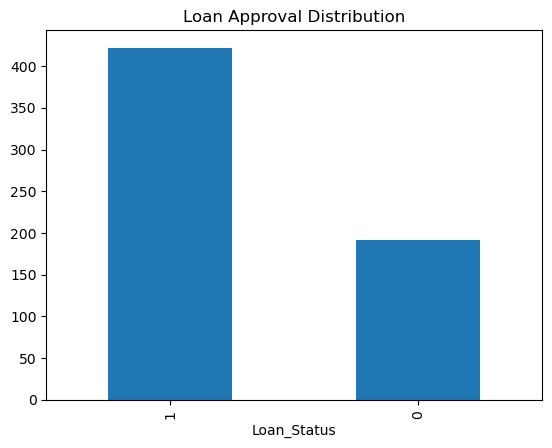

In [45]:
import matplotlib.pyplot as plt

df["Loan_Status"].value_counts().plot(
    kind="bar"
)

plt.title("Loan Approval Distribution")
plt.show()

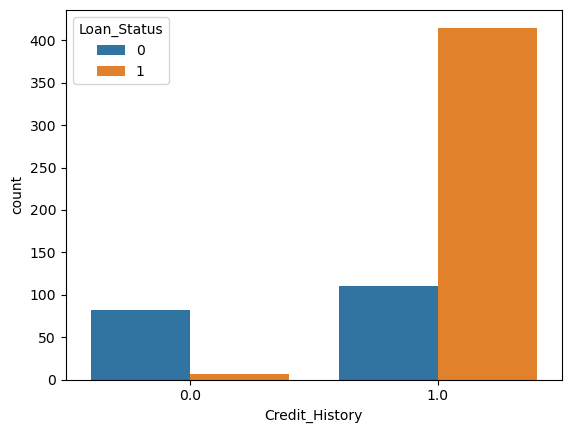

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x="Credit_History",
    hue="Loan_Status",
    data=df
)

plt.show()

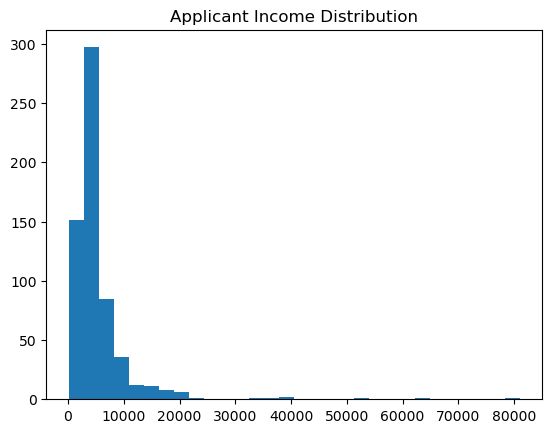

In [47]:
import matplotlib.pyplot as plt

plt.hist(
    df["ApplicantIncome"],
    bins=30
)

plt.title("Applicant Income Distribution")
plt.show()

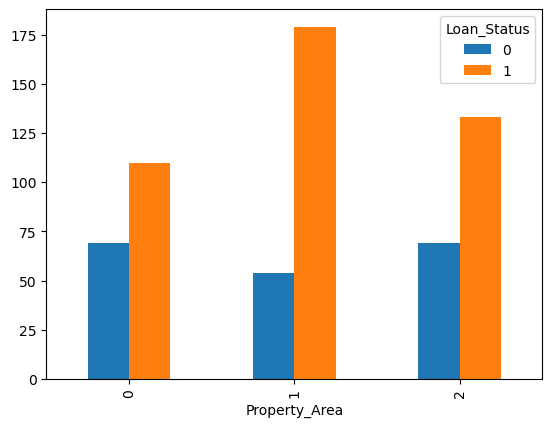

In [48]:
pd.crosstab(
    df["Property_Area"],
    df["Loan_Status"]
).plot(kind="bar")

plt.show()

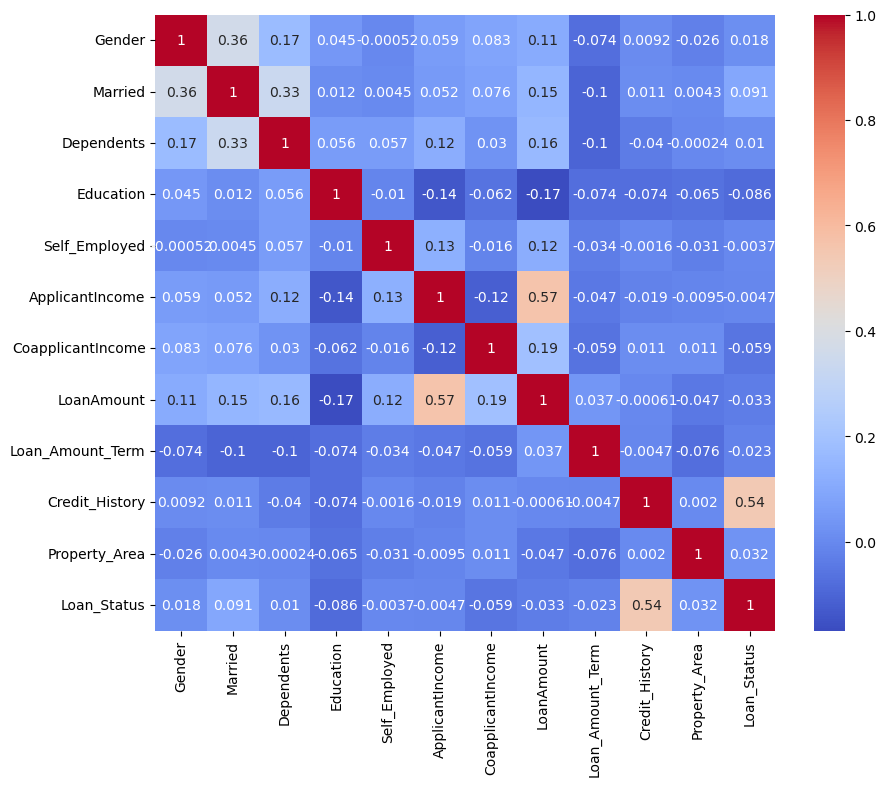

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

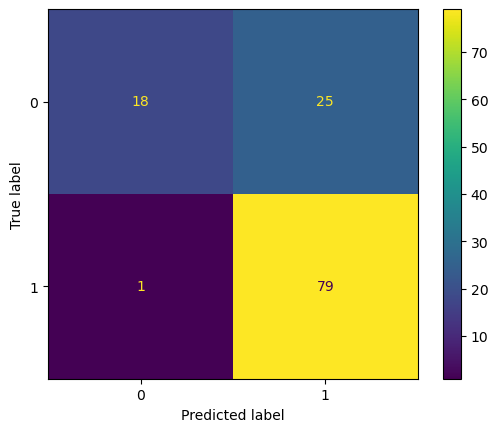

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

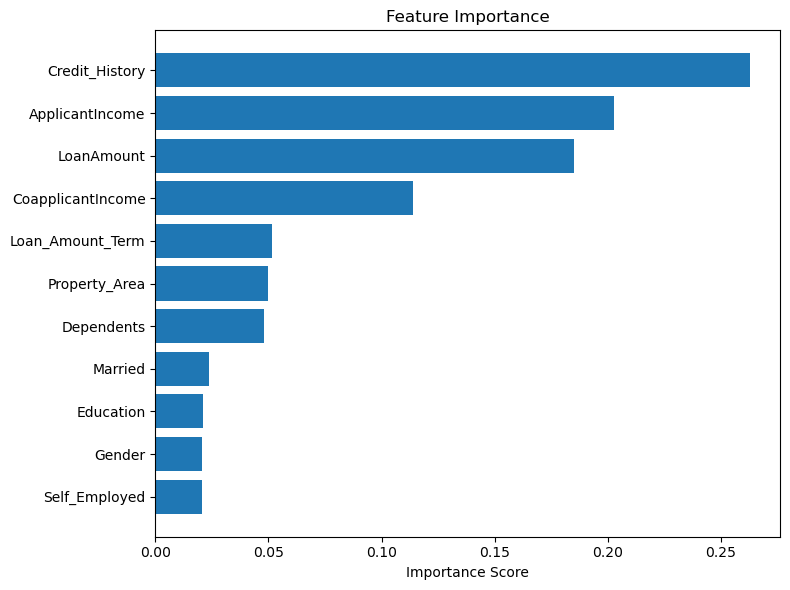

In [51]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(8,6))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [53]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [54]:
import streamlit as st
import joblib 
import pandas as pd


In [56]:
model = joblib.load("loan_model.pkl")
st.title("Loan Approval Prediction")
income = st.number_input("Applicant Income")
loan = st.number_input("Loan Amount")
credit = st.selectbox("Credit History", [0.1])

if st.button("Predict"):
    data = pd.DataFrame({
        "ApplicantIncome":[income],
        "LoanAmount": [loan],
        "Credit_History":[credit]})
    prediction = model.predict(data)

    if prediction[0] == 1:
        st.success("Loan Approved")
    else:
        st.error("Loan Rejected")
        

2026-06-20 13:15:23.423 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-20 13:15:26.742 
  command:

    streamlit run C:\Users\Asus\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-20 13:15:26.744 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-20 13:15:26.745 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-20 13:15:26.746 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-20 13:15:26.748 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-20 13:15:26.749 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-20 13:15:26.751 Session state does not f